# 00. Estrategia de Datos y Decisión de Modelado — Proyecto CRUZBER

**Proyecto:** Modelo de Predicción de Demanda — CRUZBER  
**ISDI MDA-13 | Fecha:** Marzo 2026  
**Tipo de notebook:** Documento estratégico de trazabilidad  
**Propósito:** Registrar el análisis completo de los datos disponibles, los hallazgos críticos y las decisiones de modelado adoptadas, de forma que cualquier miembro del equipo pueda entender el porqué de cada elección arquitectónica.

---

> *Este notebook NO contiene entrenamiento de modelos. Es el documento de referencia estratégica del proyecto. Debe leerse antes de ejecutar cualquier notebook de modelado (05 en adelante).*

---

## Índice

1. Contexto del proyecto y datos de partida
2. Inventario completo de datos disponibles
3. Análisis crítico por archivo — nuevos datos internos
4. Hallazgos clave que cambian la estrategia
5. Decisión estratégica: foco en cliente nacional
6. Justificación de la exclusión de exportación
7. Problema de granularidad: por qué no modelar a nivel cliente×SKU
8. Arquitectura de modelos definitiva
9. Plan de enriquecimiento de features (Notebook 15)
10. Roadmap futuro — Notebook 16 y más allá
11. Registro de decisiones documentadas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

DATA_DIR = '../Datasets'
DATA_INT = '../Datasets/Datos Internos'

print("Librerias cargadas. Notebook de trazabilidad estrategica.")
print(f"Directorio de datos: {os.path.abspath(DATA_DIR)}")

Librerias cargadas. Notebook de trazabilidad estrategica.
Directorio de datos: c:\Users\03946542\OneDrive - Mango\ISDI_MDA13\Proyecto-CRUZBER-MDA\Datasets


## 1. Contexto del Proyecto y Datos de Partida

### ¿Qué es CRUZBER?
CRUZBER es un **distribuidor B2B nacional** de equipamiento de ciclismo y portaequipajes en España. Sus clientes son tiendas de bicicletas, distribuidores, flotas de empresas y nuevos canales digitales. Opera en el mercado nacional con ~2.000 clientes activos.

### ¿Qué problema resolvemos?
Predecir la demanda semanal con suficiente antelación para:
- Planificar pedidos a proveedor (lead time 4–12 semanas)
- Posicionar stock en almacenes regionales antes de picos de temporada
- Gestionar reservas de cuentas FLEET sin inmovilizar capital innecesario
- Sustituir la planificación basada en intuición del equipo comercial por predicción cuantitativa

### Evolución del proyecto hasta este notebook
Iteraciones 1–9 (Notebooks 03–14) utilizaron `df_final_modelado.csv` (252,836 filas, granularidad SKU × Municipio × Semana). El mejor resultado alcanzado fue:

| Métrica | Iteración 9 (mejor modelo municipal) |
|---------|--------------------------------------|
| MAE | 0.610 unidades |
| MAPE | 17.6% |
| R² | 0.31 |
| Overfitting (brecha RMSE) | 47.8% |

La evaluación crítica identificó que la granularidad municipal era subóptima para un distribuidor B2B: el municipio es un proxy geográfico del cliente, no una unidad de decisión real.

Con la incorporación de nuevos datos internos (carpeta `Datos Internos/`), se reevalúa la estrategia completa.

## 2. Inventario Completo de Datos Disponibles

Se dispone de **11 archivos** organizados en tres categorías:

In [2]:
inventario = pd.DataFrame([
    {'Archivo': 'LineasAlbaranCliente.xlsx',      'Tipo': 'Interno', 'Filas': '938,230', 'Cols': 20, 'Descripcion': 'Transacciones de venta (albaranes) 2019-2024'},
    {'Archivo': 'MaestroArticulos.xlsx',           'Tipo': 'Interno', 'Filas': '30,531',  'Cols': 29, 'Descripcion': 'Catalogo completo de articulos con previsiones y stock'},
    {'Archivo': 'MaestroClientes.xlsx',            'Tipo': 'Interno', 'Filas': '3,986',   'Cols': 15, 'Descripcion': 'Maestro de clientes con tipo, zona y ciclo de vida'},
    {'Archivo': 'MaestroMunicipios.xlsx',          'Tipo': 'Interno', 'Filas': '8,146',   'Cols': 5,  'Descripcion': 'Jerarquia geografica municipio->provincia->autonomia'},
    {'Archivo': 'MaestroProvincias.xlsx',          'Tipo': 'Interno', 'Filas': '52',      'Cols': 7,  'Descripcion': 'Provincias espanolas con codigo de autonomia'},
    {'Archivo': 'MaestroFamilias.xlsx',            'Tipo': 'Interno', 'Filas': '375',     'Cols': 3,  'Descripcion': 'Familias y subfamilias de producto'},
    {'Archivo': 'Familias Articulos.xlsx',         'Tipo': 'Interno', 'Filas': '483',     'Cols': 6,  'Descripcion': 'Taxonomia enriquecida: gama, tipo, material'},
    {'Archivo': 'Agrupacion Canales venta.xlsx',   'Tipo': 'Interno', 'Filas': '32',      'Cols': 10, 'Descripcion': 'Canales con objetivos anuales 2020-2024'},
    {'Archivo': 'MaestroNaciones.xlsx',            'Tipo': 'Interno', 'Filas': '255',     'Cols': 3,  'Descripcion': 'Paises con objetivo de ventas (fuera de scope nacional)'},
    {'Archivo': 'Calendario Ciclismo 22_24.xlsx',  'Tipo': 'Externo', 'Filas': '2,249',   'Cols': 9,  'Descripcion': 'Pruebas ciclistas 2022-2024 por provincia y modalidad'},
    {'Archivo': 'clima_semanal_openmeteo.csv',     'Tipo': 'Externo', 'Filas': '12,838',  'Cols': 6,  'Descripcion': 'Datos meteorologicos semanales por provincia 2020-2026'},
])

print(inventario.to_string(index=False))
print(f"\nTotal archivos: {len(inventario)}")
print(f"Datos internos: {(inventario['Tipo']=='Interno').sum()} archivos")
print(f"Datos externos: {(inventario['Tipo']=='Externo').sum()} archivos")

                       Archivo    Tipo   Filas  Cols                                             Descripcion
     LineasAlbaranCliente.xlsx Interno 938,230    20            Transacciones de venta (albaranes) 2019-2024
         MaestroArticulos.xlsx Interno  30,531    29  Catalogo completo de articulos con previsiones y stock
          MaestroClientes.xlsx Interno   3,986    15      Maestro de clientes con tipo, zona y ciclo de vida
        MaestroMunicipios.xlsx Interno   8,146     5    Jerarquia geografica municipio->provincia->autonomia
        MaestroProvincias.xlsx Interno      52     7            Provincias espanolas con codigo de autonomia
          MaestroFamilias.xlsx Interno     375     3                      Familias y subfamilias de producto
       Familias Articulos.xlsx Interno     483     6             Taxonomia enriquecida: gama, tipo, material
 Agrupacion Canales venta.xlsx Interno      32    10                 Canales con objetivos anuales 2020-2024
          MaestroNa

## 3. Análisis Crítico por Archivo — Nuevos Datos Internos

### 3.1 LineasAlbaranCliente.xlsx — El archivo más importante

Es la fuente primaria de transacciones. Contiene **938,230 líneas de albarán** desde 2019 hasta septiembre 2024 con las siguientes columnas clave:

| Columna | Tipo | Relevancia para el modelo |
|---------|------|---------------------------|
| `CodigoCliente` | int64 | **Granularidad de cliente** — habilita modelo B2B real |
| `SerieAlbaran` | object | **Discrimina Nacional vs Exportación** (numérica = nacional) |
| `FechaAlbaran` | object | Formato texto español ("viernes, 30 de julio de 2021") — parseable |
| `CodigoArticulo` | object | SKU vendido |
| `Unidades` | float64 | Variable objetivo. Mediana=1, media=2.24, max=2,000 |
| `%Descuento` | float64 | Descuento comercial estándar (~46% promedio B2B) — NO es señal promocional |
| `%Descuento2` | float64 | Descuento promocional adicional (2.6% de filas > 0) — SÍ es señal |
| `PorMargenBeneficio` | float64 | Margen por línea — feature potencial para segmentación |
| `ImporteNeto` | float64 | Ingresos netos por línea |

**Aclaración importante sobre descuentos:**
El `%Descuento` (media 46%) es el descuento comercial de tarifa B2B que CRUZBER aplica siempre a sus clientes — es la estructura de precios habitual, no una promoción. El `%Descuento2` (solo 2.6% de filas) es el descuento promocional adicional que actúa como señal de demanda (identificado en Iteración 6 con efecto x4.7 sobre unidades).

**Devoluciones:** 25,125 registros con `Unidades < 0` (2.7% del total). Deben excluirse del panel de demanda o tratarse como feature separada.

In [3]:
# Carga y validacion de LineasAlbaranCliente
print("Cargando LineasAlbaranCliente.xlsx...")
df_raw = pd.read_excel(f'{DATA_INT}/LineasAlbaranCliente.xlsx')
print(f"  Filas totales: {len(df_raw):,}")
print(f"  Columnas: {df_raw.shape[1]}")
print(f"  Clientes unicos: {df_raw['CodigoCliente'].nunique():,}")
print(f"  SKUs unicos: {df_raw['CodigoArticulo'].nunique():,}")
print(f"  Unidades negativas (devoluciones): {(df_raw['Unidades'] < 0).sum():,} ({(df_raw['Unidades'] < 0).mean()*100:.1f}%)")
print(f"  %Descuento2 > 0: {(df_raw['%Descuento2'] > 0).sum():,} ({(df_raw['%Descuento2'] > 0).mean()*100:.1f}%)")
print()

# Parsing de fechas en español
month_map = {
    'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,
    'julio':7,'agosto':8,'septiembre':9,'octubre':10,'noviembre':11,'diciembre':12
}

def parse_spanish_date(s):
    try:
        # Remove leading weekday (everything up to and including the first comma+space)
        clean = re.sub(r'^[^,]+,\s*', '', str(s))
        parts = clean.split(' de ')
        return pd.Timestamp(
            year=int(parts[2].strip()),
            month=month_map.get(parts[1].strip().lower(), 0),
            day=int(parts[0].strip())
        )
    except:
        return pd.NaT

df_raw['fecha'] = df_raw['FechaAlbaran'].apply(parse_spanish_date)
df_raw['anio']  = df_raw['fecha'].dt.year

print(f"  Rango de fechas: {df_raw['fecha'].min().date()} -> {df_raw['fecha'].max().date()}")
print(f"  Anos unicos: {sorted(df_raw['anio'].dropna().unique().astype(int).tolist())}")

Cargando LineasAlbaranCliente.xlsx...
  Filas totales: 938,230
  Columnas: 20
  Clientes unicos: 2,343
  SKUs unicos: 4,915
  Unidades negativas (devoluciones): 25,125 (2.7%)
  %Descuento2 > 0: 34,498 (3.7%)

  Rango de fechas: 2019-01-02 -> 2024-09-26
  Anos unicos: [2019, 2020, 2021, 2022, 2023, 2024]


=== NACIONAL vs EXPORTACION (2022-2024, unidades positivas) ===
   Segmento Filas 2022-2024 % Filas  Clientes unicos  SKUs unicos Ingresos netos (EUR) % Ingresos
   NACIONAL         449,327   95.7%             2055         3414        EUR41,572,693      97.3%
EXPORTACION          20,060    4.3%               91         1298         EUR1,148,906       2.7%

Series NACIONALES (numerico): [22, 23, 24]
Series EXPORTACION (texto): ['V4', 'FS24', 'C7', 'FS23', 'A22', 'A23', 'A24', 'FS22']


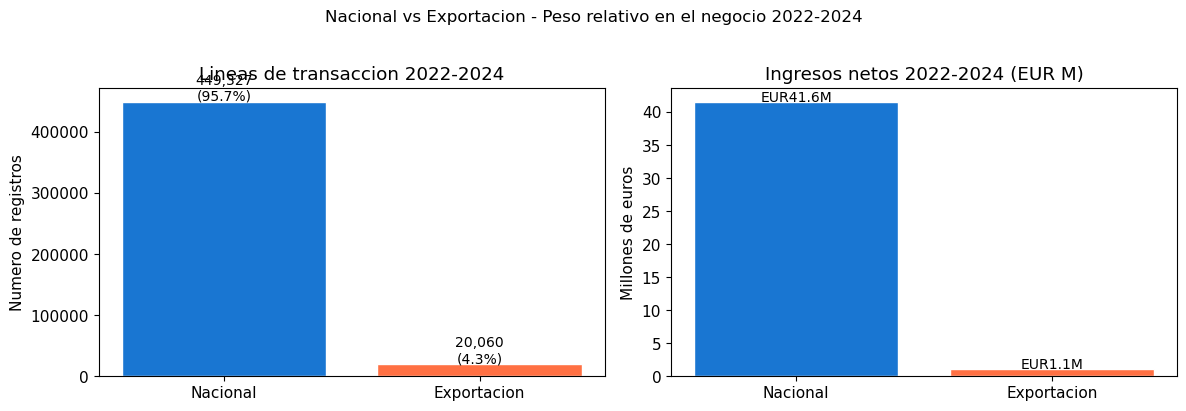

In [4]:
# Clasificacion Nacional vs Exportacion por serie
df_raw['es_nacional'] = df_raw['SerieAlbaran'].astype(str).str.match(r'^\d+$')

# Filtro 2022-2024 con unidades positivas
df22 = df_raw[(df_raw['anio'].between(2022, 2024)) & (df_raw['Unidades'] > 0)].copy()
df_nac22 = df22[df22['es_nacional']]
df_exp22 = df22[~df22['es_nacional']]

resumen_split = pd.DataFrame({
    'Segmento': ['NACIONAL', 'EXPORTACION'],
    'Filas 2022-2024': [f"{len(df_nac22):,}", f"{len(df_exp22):,}"],
    '% Filas': [f"{len(df_nac22)/len(df22)*100:.1f}%", f"{len(df_exp22)/len(df22)*100:.1f}%"],
    'Clientes unicos': [df_nac22['CodigoCliente'].nunique(), df_exp22['CodigoCliente'].nunique()],
    'SKUs unicos': [df_nac22['CodigoArticulo'].nunique(), df_exp22['CodigoArticulo'].nunique()],
    'Ingresos netos (EUR)': [f"EUR{df_nac22['ImporteNeto'].sum():,.0f}", f"EUR{df_exp22['ImporteNeto'].sum():,.0f}"],
    '% Ingresos': [f"{df_nac22['ImporteNeto'].sum()/(df22['ImporteNeto'].sum())*100:.1f}%",
                   f"{df_exp22['ImporteNeto'].sum()/(df22['ImporteNeto'].sum())*100:.1f}%"]
})

print("=== NACIONAL vs EXPORTACION (2022-2024, unidades positivas) ===")
print(resumen_split.to_string(index=False))
print()
print("Series NACIONALES (numerico):", sorted(df22[df22['es_nacional']]['SerieAlbaran'].unique().astype(int).tolist()))
print("Series EXPORTACION (texto):", [s for s in df22[~df22['es_nacional']]['SerieAlbaran'].value_counts().head(8).index.tolist()])

# Grafico de barras ingresos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Filas
axes[0].bar(['Nacional', 'Exportacion'], [len(df_nac22), len(df_exp22)],
            color=['#1976D2', '#FF7043'], edgecolor='white')
axes[0].set_title('Lineas de transaccion 2022-2024')
axes[0].set_ylabel('Numero de registros')
for i, v in enumerate([len(df_nac22), len(df_exp22)]):
    axes[0].text(i, v + 2000, f'{v:,}\n({v/len(df22)*100:.1f}%)', ha='center', fontsize=10)

# Ingresos
axes[1].bar(['Nacional', 'Exportacion'],
            [df_nac22['ImporteNeto'].sum()/1e6, df_exp22['ImporteNeto'].sum()/1e6],
            color=['#1976D2', '#FF7043'], edgecolor='white')
axes[1].set_title('Ingresos netos 2022-2024 (EUR M)')
axes[1].set_ylabel('Millones de euros')
for i, v in enumerate([df_nac22['ImporteNeto'].sum()/1e6, df_exp22['ImporteNeto'].sum()/1e6]):
    axes[1].text(i, v + 0.05, f'EUR{v:.1f}M', ha='center', fontsize=10)

plt.suptitle('Nacional vs Exportacion - Peso relativo en el negocio 2022-2024', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 3.2 MaestroArticulos.xlsx — El archivo de enriquecimiento más valioso

Contiene 30,531 artículos con atributos que no estaban en el modelo anterior. Los campos más relevantes para el forecasting:

| Campo | Cobertura útil | Por qué es valioso |
|-------|----------------|-------------------|
| `PrevisionVentasAA` | 1,954 SKUs con valor > 0 | **Máxima prioridad**: contiene la inteligencia comercial del equipo de ventas (contratos, estacionalidad, tendencias). Es una feature exógena que ningún modelo ML puede inferir. |
| `FactorCrecimiento` | 4,435 SKUs con valor ≠ 1 | Tendencia esperada por producto. Multiplica la previsión base. |
| `AreaCompetenciaLc` | 13 categorías | Segmentación competitiva más rica que las 2 familias actuales (CRUZ/FIRRAK). |
| `StockMinimo` / `StockMaximo` | Mediana = 1 | Valor limitado como feature numérica (muy cercanos a cero), pero útil para definir umbrales de alerta. |
| `TarifaExport` / `TarifaNacional` | Binario | Indica si el SKU tiene precio diferenciado para exportación — relevante al separar canales. |
| `Obsoleto` | 14,551 SKUs obsoletos (48%) | **Filtro obligatorio**: los SKUs obsoletos no deben aparecer en predicciones futuras. |

**Hallazgo sobre PrevisionVentasAA:**
CRUZBER ya tiene un sistema interno de previsión de ventas. Si el modelo ML no supera esta previsión interna, **no hay motivo para desplegarlo**. El benchmark contra `PrevisionVentasAA` debe ser un KPI obligatorio del proyecto.

In [5]:
ma = pd.read_excel(f'{DATA_INT}/MaestroArticulos.xlsx')
print(f"MaestroArticulos: {ma.shape[0]:,} SKUs x {ma.shape[1]} columnas")
print()

# Distribucion TipoABC
abc = ma['TipoABC'].value_counts()
print("TipoABC:")
for k, v in abc.items():
    print(f"  {k}: {v:,} ({v/len(ma)*100:.1f}%)")
print()

# Obsoletos
obs = ma['Obsoleto'].value_counts()
print("Obsoleto:")
for k, v in obs.items():
    print(f"  {k}: {v:,} ({v/len(ma)*100:.1f}%)")
print()

# Previsiones
prev_nz = (ma['PrevisionVentasAA'] > 0).sum()
fc_diff  = (ma['FactorCrecimiento'] != 1).sum()
print(f"PrevisionVentasAA > 0: {prev_nz:,} SKUs ({prev_nz/len(ma)*100:.1f}%)")
print(f"FactorCrecimiento != 1: {fc_diff:,} SKUs ({fc_diff/len(ma)*100:.1f}%)")
print()

# AreaCompetencia
if 'AreaCompetenciaLc' in ma.columns:
    print("AreaCompetenciaLc (top 10 categorias):")
    print(ma['AreaCompetenciaLc'].value_counts().head(10).to_string())

MaestroArticulos: 30,531 SKUs x 29 columnas

TipoABC:
  C: 25,955 (85.0%)
  B: 2,531 (8.3%)
  A: 1,897 (6.2%)

Obsoleto:
  No: 15,980 (52.3%)
  Si: 14,551 (47.7%)

PrevisionVentasAA > 0: 1,954 SKUs (6.4%)
FactorCrecimiento != 1: 4,435 SKUs (14.5%)

AreaCompetenciaLc (top 10 categorias):
AreaCompetenciaLc
Sistemas de t. turismos          5542
Sistemas de t. veh. comercial    2955
Acc. bolas de enganche           2027
Acc. RMS                          667
Sistemas de t. 4x4                625
Acc. cofres de techo              514
Despiece de accesorios            459
Acc. cadenas de nieve             423
Acc. portabicis techo             205
Acc. portaesquíes                 100


### 3.3 MaestroClientes.xlsx — Granularidad real del negocio B2B

Con 3,986 clientes registrados (2,250 activos), este archivo confirma que CRUZBER opera con una base de clientes **gestionable para modelado individual**. Los campos más relevantes:

| Campo | Valores | Relevancia |
|-------|---------|-----------|
| `TipoCruz` | 31 tipos (UsuarioCR, Cruz5, CruzND, FLEET, Web...) | Segmentación más precisa que `agrupacion_canal` |
| `CodigoJefeZona` | 10 zonas | La estructura comercial real de CRUZBER — mejor que las 6 regiones definidas manualmente |
| `FechaAlta` / `FechaBajaLc` | 2006–2024 | Ciclo de vida del cliente — churn rate: 43.6% |
| `Municipio` / `Provincia` | 1,308 municipios, 97 provincias | Ubicación geográfica de cada cliente |

**Insight sobre el churn:** El 43.6% de clientes inactivos no significa que el negocio esté en declive — en B2B es habitual que clientes eventuales compren 1-2 veces y no repitan. Sin embargo, debe gestionarse correctamente en el modelo: solo predecir demanda de clientes activos (FechaBajaLc nulo).

**¿Por qué no modelamos a nivel cliente×SKU?** Ver Sección 7.

In [6]:
mc = pd.read_excel(f'{DATA_INT}/MaestroClientes.xlsx')
print(f"MaestroClientes: {mc.shape[0]:,} clientes x {mc.shape[1]} columnas")
print()

activos   = mc['FechaBajaLc'].isnull().sum()
inactivos = mc['FechaBajaLc'].notnull().sum()
print(f"Activos (FechaBajaLc nulo):    {activos:,} ({activos/len(mc)*100:.1f}%)")
print(f"Inactivos (con fecha de baja): {inactivos:,} ({inactivos/len(mc)*100:.1f}%)")
print()

# TipoCruz distribution (top 10)
print("TipoCruz - Top 10 tipos:")
tc = mc['TipoCruz'].value_counts().head(10)
for k, v in tc.items():
    print(f"  {k}: {v:,} ({v/len(mc)*100:.1f}%)")
print()

# Zonas
zona_col = None
for col in mc.columns:
    if 'JefeZona' in col or 'jefezona' in col.lower():
        zona_col = col
        break

if zona_col:
    zonas = mc[zona_col].nunique()
    print(f"Zonas comerciales ({zona_col}): {zonas} zonas unicas")
    print(mc[zona_col].value_counts().to_string())
else:
    print("Columna CodigoJefeZona no encontrada. Columnas disponibles:")
    print([c for c in mc.columns if 'zona' in c.lower() or 'jefe' in c.lower()])

MaestroClientes: 3,986 clientes x 15 columnas

Activos (FechaBajaLc nulo):    2,250 (56.4%)
Inactivos (con fecha de baja): 1,736 (43.6%)

TipoCruz - Top 10 tipos:
  UsuarioCR: 1,077 (27.0%)
  Cruz5: 820 (20.6%)
  CruzND: 426 (10.7%)
  Cruz3: 359 (9.0%)
  CruzCON: 199 (5.0%)
  Cruz2: 137 (3.4%)
  UsuarioRK: 132 (3.3%)
  CruzFLEET: 105 (2.6%)
  Cruz2P: 101 (2.5%)
  CruzExD: 100 (2.5%)

Zonas comerciales (CodigoJefeZona_): 10 zonas unicas
CodigoJefeZona_
100    1431
0      1218
84      534
224     477
99      159
325      67
214      47
180      37
164      14
92        2


### 3.4 Familias Articulos.xlsx — Taxonomía enriquecida de producto

Aporta tres categorías de producto que no existen en `df_final_modelado.csv`:

| Campo | Valores únicos | Ejemplos |
|-------|---------------|----------|
| `CR_GamaProducto` | **4** | PC (Portaequipajes de coche), CV (Ciclismo), ACC (Accesorios), OEM |
| `CR_TipoProducto` | **5** | Portaequipajes, Barras, Fijaciones, Accesorios, OEM |
| `CR_MaterialAgrupacion` | **9** | Acero, Aluminio, PortabicicletasTecho, RMS, Varios... |

Estas 4–5 categorías limpias **reemplazan ventajosamente al CodigoFamilia** del modelo actual (que solo tiene CRUZ y FIRRAK como valores útiles — demasiado grueso). Son especialmente útiles para mejorar la predicción de productos B y C con baja rotación.

La cobertura no es del 100% (algunos códigos de agrupación no tienen CR_ asignado), pero cubre la mayoría del catálogo activo.

### 3.5 Agrupacion Canales venta.xlsx — Tendencias y objetivos de canal

Confirma la estructura de 7 agrupaciones de canal y aporta **objetivos anuales de venta** que revelan tendencias estratégicas:

| Canal | 2020 | 2021 | 2022 | 2023 | 2024 | Tendencia |
|-------|------|------|------|------|------|----------|
| FLEET Nacional | EUR0.93M | EUR1.20M | EUR1.36M | EUR1.60M | **EUR1.91M** | +106% |
| Nueva Distribucion | EUR0.24M | EUR1.27M | EUR2.07M | EUR2.04M | **EUR2.11M** | +779% |
| Tradicional | EUR2.91M | EUR3.08M | EUR3.06M | EUR2.56M | **EUR2.21M** | -24% |

Estos objetivos son **features de tendencia macro** muy potentes: si el equipo directivo se propone crecer el FLEET un 20% en 2024, el modelo debe incorporar esa información.

Los canales Export (CruzExA, CruzExB, etc.) quedan **fuera del scope del proyecto** (ver Sección 6).

Columnas disponibles: ['Canal', 'Agrupación Canal', 'Tipo Agrupación', 'Objetivo Ventas 2020', 'Orden Agrupacion', 'Orden Tipo Agrupacion', 'Objetivo Ventas 2021', 'Objetivo Ventas 2022', 'Objetivo Ventas 2023', 'Objetivo Ventas 2024']
Columnas de objetivos detectadas: ['Objetivo Ventas 2020', 'Objetivo Ventas 2021', 'Objetivo Ventas 2022', 'Objetivo Ventas 2023', 'Objetivo Ventas 2024']

Objetivos de venta por canal Nacional (EUR):
  Agrupación Canal  Objetivo Ventas 2020  Objetivo Ventas 2021  Objetivo Ventas 2022  Objetivo Ventas 2023  Objetivo Ventas 2024
             FLEET                925000               1200000               1362800               1600000               1910000
Nueva Distribución                236000               1369500               2072780               2038000               2310000
  Primeros Equipos                166500                175000                206230                150000                145000
       Tradicional               2907500       

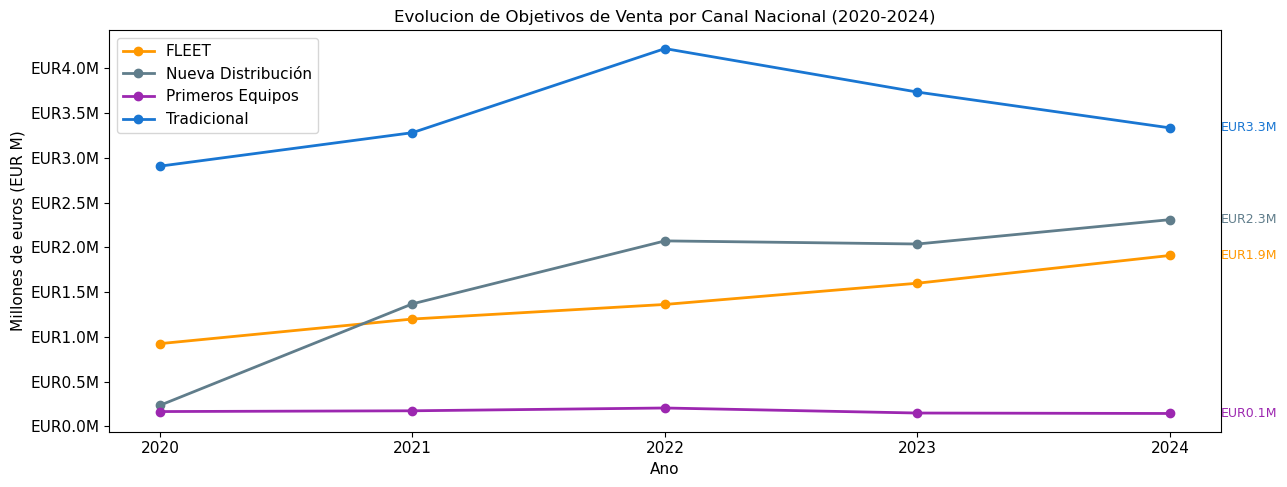

In [7]:
ac = pd.read_excel(f'{DATA_INT}/Agrupacion Canales venta.xlsx')
ac.columns = [c.strip() for c in ac.columns]

# Identificar columna de tipo de agrupacion y columna de agrupacion
tipo_col   = [c for c in ac.columns if 'Tipo' in c and 'Agrup' in c]
agrup_col  = [c for c in ac.columns if c == 'Agrupacion Canal' or ('Agrup' in c and 'Tipo' not in c)]
obj_cols   = [c for c in ac.columns if 'Objetivo' in c or 'Ventas' in c]

print("Columnas disponibles:", list(ac.columns))
print(f"Columnas de objetivos detectadas: {obj_cols}")
print()

if tipo_col and agrup_col and obj_cols:
    nat_channels = ac[ac[tipo_col[0]] == 'Nacional'].copy()
    grouped = nat_channels.groupby(agrup_col[0])[obj_cols].sum().reset_index()
    print("Objetivos de venta por canal Nacional (EUR):")
    print(grouped.to_string(index=False))
    print()

    # Plot evolution
    fig, ax = plt.subplots(figsize=(13, 5))
    year_labels = [c.replace('Objetivo', '').replace('Ventas', '').strip() for c in obj_cols]
    colors_ch = {'Tradicional': '#1976D2', 'FLEET': '#FF9800', 'Nueva Distribucion': '#4CAF50',
                 'Primeros Equipos': '#9C27B0', 'Nuevas Cuentas': '#795548'}

    for _, row in grouped.iterrows():
        canal = row[agrup_col[0]]
        vals  = [row[c]/1e6 for c in obj_cols]
        color = colors_ch.get(canal, '#607D8B')
        ax.plot(year_labels, vals, marker='o', linewidth=2, label=canal, color=color)
        ax.annotate(f"EUR{vals[-1]:.1f}M", xy=(year_labels[-1], vals[-1]),
                    xytext=(len(year_labels)-0.8, vals[-1]),
                    color=color, fontsize=9, va='center')

    ax.set_title('Evolucion de Objetivos de Venta por Canal Nacional (2020-2024)', fontsize=12)
    ax.set_ylabel('Millones de euros (EUR M)')
    ax.set_xlabel('Ano')
    ax.legend(loc='upper left')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'EUR{x:.1f}M'))
    plt.tight_layout()
    plt.show()
else:
    print("No se pudieron identificar columnas de canal/objetivo de forma automatica.")
    print("Estructura del archivo:")
    print(ac.head())

## 4. Hallazgos Clave que Cambian la Estrategia

Tras el análisis de los nuevos datos internos, se identifican **cinco hallazgos** que modifican la estrategia de modelado respecto a las iteraciones 1–9:

---

### Hallazgo 1 — Tenemos granularidad de cliente (B2B real)
`LineasAlbaranCliente` contiene `CodigoCliente`, con 2,055 clientes activos en 2022–2024. Esto habilita modelado a nivel de cliente individual — el nivel más accionable en B2B forecasting. Sin embargo, la viabilidad depende de la densidad de datos (ver Hallazgo 3).

### Hallazgo 2 — CRUZBER ya tiene sus propias previsiones
`MaestroArticulos.PrevisionVentasAA` contiene previsiones internas para 1,954 SKUs. Esto tiene dos implicaciones:
- **Benchmark obligatorio**: el modelo ML debe superar esta previsión interna para justificar su despliegue.
- **Feature potente**: la previsión interna incorpora inteligencia de negocio (contratos firmados, tendencias de mercado) que ningún modelo puede inferir de datos históricos.

### Hallazgo 3 — El modelo cliente×SKU tiene un problema de sparsity crítico
Los 123,154 pares activos (Cliente×SKU) × 143 semanas = 17.6M filas potenciales, con solo 449,327 filas reales → fill rate del **2.6%**. Con 97.4% de semanas en cero, las series temporales tienen 3–4 observaciones reales en todo el período. Ningún algoritmo de ML puede aprender patrones fiables de eso.

### Hallazgo 4 — La exportación representa el 4.3% de filas y 2.7% de ingresos
La separación entre nacional y exportación es **trivial y definitiva**: las series numéricas de albarán (19–24) son nacionales; cualquier serie alfanumérica (V4, FS, C7, A...) es exportación o ajuste contable. La exportación tiene dinámicas completamente distintas (mercados, monedas, estacionalidades) y una escala diez veces menor.

### Hallazgo 5 — Los canales de exportación tienen su propio universo
Los canales Export (CruzExA, CruzExB, Distribución Export...) con objetivos de EUR8M+ anuales merecen un proyecto de forecasting propio. Mezclarlos con el negocio nacional contaminaría ambos modelos.

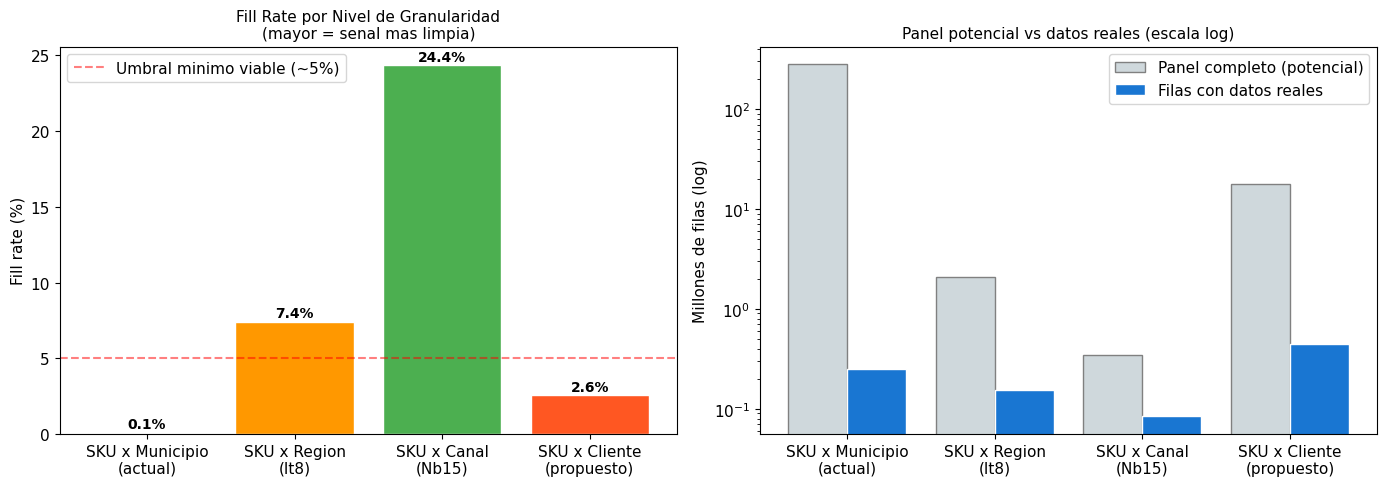

Fill rates por nivel de granularidad:
  SKU x Municipio (actual): 0.1% -- [X] INVIABLE (demasiado escaso)
  SKU x Region (It8): 7.4% -- [OK] VIABLE
  SKU x Canal (Nb15): 24.4% -- [OK] VIABLE
  SKU x Cliente (propuesto): 2.6% -- [X] INVIABLE (demasiado escaso)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: sparsity comparison across granularity levels
granularidades = ['SKU x Municipio\n(actual)', 'SKU x Region\n(It8)', 'SKU x Canal\n(Nb15)', 'SKU x Cliente\n(propuesto)']
filas_activas  = [252836, 155567, 252836/3, 449327]
filas_panel    = [280e6,  2.1e6,  346e3,    17.6e6]
fill_rates     = [f/p*100 for f, p in zip(filas_activas, filas_panel)]

colors_fr = ['#FF5722' if fr < 5 else '#FF9800' if fr < 20 else '#4CAF50' for fr in fill_rates]
bars = axes[0].bar(granularidades, fill_rates, color=colors_fr, edgecolor='white')
axes[0].set_title('Fill Rate por Nivel de Granularidad\n(mayor = senal mas limpia)', fontsize=11)
axes[0].set_ylabel('Fill rate (%)')
axes[0].axhline(y=5, color='red', linestyle='--', alpha=0.5, label='Umbral minimo viable (~5%)')
for bar, fr in zip(bars, fill_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{fr:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].legend()

# Right: rows in panel vs active rows (log scale)
x = range(len(granularidades))
axes[1].bar([xi - 0.2 for xi in x], [p/1e6 for p in filas_panel], width=0.4,
            label='Panel completo (potencial)', color='#CFD8DC', edgecolor='grey')
axes[1].bar([xi + 0.2 for xi in x], [f/1e6 for f in filas_activas], width=0.4,
            label='Filas con datos reales', color='#1976D2', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(granularidades)
axes[1].set_title('Panel potencial vs datos reales (escala log)', fontsize=11)
axes[1].set_ylabel('Millones de filas (log)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Fill rates por nivel de granularidad:")
for g, fr in zip(granularidades, fill_rates):
    viab = "[OK] VIABLE" if fr >= 5 else "[X] INVIABLE (demasiado escaso)"
    print(f"  {g.replace(chr(10),' ')}: {fr:.1f}% -- {viab}")

## 5. Decisión Estratégica: Foco en Cliente Nacional

### La decisión
**A partir de este punto, el proyecto CRUZBER se centra exclusivamente en el mercado nacional español.** La exportación queda fuera del scope del modelo de demanda actual.

### Criterio de filtrado técnico
```python
# Filtro aplicable a LineasAlbaranCliente
df_nacional = df[df['SerieAlbaran'].astype(str).str.match(r'^\d+$')]
# Series nacionales: 19, 20, 21, 22, 23, 24 (formato numerico = anio de albaran)
```

### Justificación de la decisión

**Argumento 1 — Peso del negocio**
- Nacional: 449,327 transacciones (95.7%) | EUR41.6M (97.3%) en 2022–2024
- Exportación: 20,060 transacciones (4.3%) | EUR1.1M (2.7%)
La exportación representa menos del 3% de los ingresos. Un error en la predicción nacional tiene 36 veces más impacto económico que un error equivalente en exportación.

**Argumento 2 — Heterogeneidad estructural**
Los mercados de exportación (distribuidor en Francia, fleet en Alemania, retailer en Portugal) tienen:
- Estacionalidades diferentes
- Monedas y precios distintos
- Canales de distribución propios
- Sin relación con el calendario ciclista español
- Sin cobertura en los datos de clima OpenMeteo disponibles

Mezclarlos con el mercado nacional distorsiona los patrones de ambos.

**Argumento 3 — Alineación con la decisión de negocio**
CRUZBER gestiona la exportación de forma separada (zona "Export" en Agrupacion Canales). Sus equipos comerciales, almacenes y KPIs son distintos. Un modelo de demanda nacional resuelve el problema de planificación que el equipo de operaciones de España tiene hoy.

**Argumento 4 — Calidad de datos**
Las series de exportación incluyen ajustes contables (INC = incidencias, DV = devoluciones, RC = rectificaciones) que distorsionan el volumen real de demanda.

## 6. Problema de Granularidad: Por Qué No Modelo a Nivel Cliente×SKU

Esta sección documenta formalmente por qué se descarta el modelo a nivel Cliente×SKU individual, a pesar de ser el nivel más intuitivo en un negocio B2B.

### Los números del panel

| Parámetro | Valor |
|-----------|-------|
| Pares activos (Cliente×SKU) nacional 2022–2024 | 123,154 |
| Semanas en el período | 143 |
| Panel completo: 123,154 × 143 | **17,611,022 filas** |
| Filas con ventas reales | 449,327 |
| **Fill rate** | **2.6%** |
| Semanas de venta por par (mediana) | **1** |
| Semanas de venta por par (media) | **3.7** |

### ¿Por qué el 2.6% de fill rate es un problema fatal?

Un modelo de series temporales necesita suficientes observaciones no-cero para aprender patrones. Con una mediana de 1 venta en 143 semanas por par (Cliente×SKU):

- La serie temporal tiene 1 punto de datos real y 142 ceros
- No hay lag-1w, lag-4w ni rolling mean que tenga señal
- El modelo aprendería "siempre cero" — accuracy artificialmente alta, pero inútil
- Métricas como MAPE son inestables con tantos ceros

### Alternativa viable: nivel cliente agregado (sin SKU)
Un modelo **Total ventas × Cliente × Semana** (2,055 clientes × 143 semanas = 294K filas) sería viable, con fill rate estimado >60%. Permite predecir "¿cuánto va a gastar este cliente esta semana?" — útil para gestión de cuentas y detección de churn. Este modelo se plantea como **Notebook 16 (trabajo futuro)**.

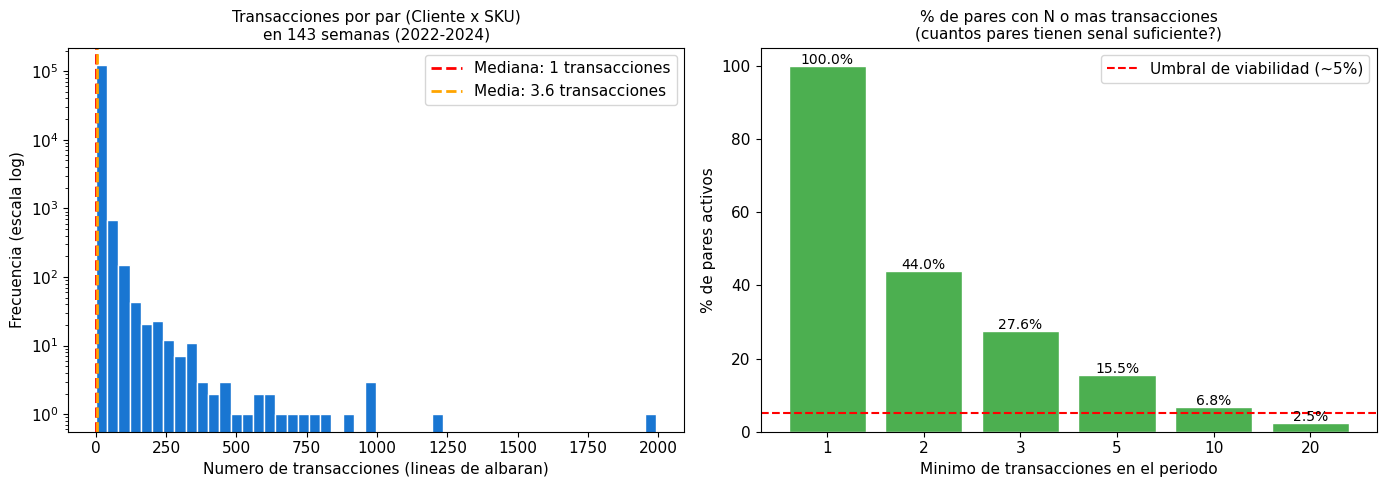


Resumen de pares (Cliente x SKU):
  Total pares activos: 123,154
  Mediana transacciones/par: 1
  Pares con >= 5 transacciones: 19,102 (15.5%)
  Pares con >= 10 transacciones: 8,385 (6.8%)


In [9]:
# Visualizar la distribucion de transacciones por par Cliente x SKU
df22 = df_raw[
    (df_raw['anio'].between(2022, 2024)) &
    (df_raw['Unidades'] > 0) &
    (df_raw['SerieAlbaran'].astype(str).str.match(r'^\d+$'))
].copy()

pair_counts = df22.groupby(['CodigoCliente', 'CodigoArticulo']).size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribucion de transacciones por par (histogram)
axes[0].hist(pair_counts.values, bins=50, color='#1976D2', edgecolor='white', log=True)
axes[0].axvline(pair_counts.median(), color='red', linestyle='--', linewidth=2,
                label=f'Mediana: {pair_counts.median():.0f} transacciones')
axes[0].axvline(pair_counts.mean(), color='orange', linestyle='--', linewidth=2,
                label=f'Media: {pair_counts.mean():.1f} transacciones')
axes[0].set_title('Transacciones por par (Cliente x SKU)\nen 143 semanas (2022-2024)', fontsize=11)
axes[0].set_xlabel('Numero de transacciones (lineas de albaran)')
axes[0].set_ylabel('Frecuencia (escala log)')
axes[0].legend()

# Fill rate por umbral minimo
thresholds = [1, 2, 3, 5, 10, 20]
pcts = [(pair_counts >= t).mean() * 100 for t in thresholds]
axes[1].bar([str(t) for t in thresholds], pcts, color='#4CAF50', edgecolor='white')
axes[1].axhline(y=5, color='red', linestyle='--', label='Umbral de viabilidad (~5%)')
axes[1].set_title('% de pares con N o mas transacciones\n(cuantos pares tienen senal suficiente?)', fontsize=11)
axes[1].set_xlabel('Minimo de transacciones en el periodo')
axes[1].set_ylabel('% de pares activos')
axes[1].legend()
for bar, pct in zip(axes[1].patches, pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{pct:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nResumen de pares (Cliente x SKU):")
print(f"  Total pares activos: {len(pair_counts):,}")
print(f"  Mediana transacciones/par: {pair_counts.median():.0f}")
print(f"  Pares con >= 5 transacciones: {(pair_counts >= 5).sum():,} ({(pair_counts >= 5).mean()*100:.1f}%)")
print(f"  Pares con >= 10 transacciones: {(pair_counts >= 10).sum():,} ({(pair_counts >= 10).mean()*100:.1f}%)")

## 7. Arquitectura de Modelos Definitiva

Basándonos en los hallazgos anteriores, la arquitectura de modelos queda definida en dos horizontes:

---

### Horizonte inmediato — Notebook 15 (en ejecución)

| Modelo | Granularidad | Filas (aprox) | Para quién | Decisión |
|--------|-------------|---------------|------------|----------|
| **A — Nacional** | SKU × Semana | ~75K | Dirección de compras | ¿Cuánto pido al proveedor? |
| **B — Tradicional × Región** | SKU × Región × Semana | ~83K | Resp. almacén regional | ¿Dónde posiciono el stock? |
| **C — FLEET Nacional** | SKU × Semana (FLEET) | ~8K | Gestor cuentas FLEET | ¿Cuánto reservo para flotas? |

Fuente de datos: `df_final_modelado.csv` (ya preparado, 252,836 filas)  
Enriquecimiento pendiente: features de `MaestroArticulos` y `Familias Articulos` (ver Sección 8)

---

### Horizonte futuro — Notebook 16

| Modelo | Granularidad | Filas (aprox) | Para quién | Decisión |
|--------|-------------|---------------|------------|----------|
| **D — Cliente Total** | Cliente × Semana | ~300K | Equipo comercial | ¿Cuándo va a comprar cada cliente? |
| **E — Cliente × Familia** | Cliente × Familia × Semana | ~800K | Gestor de cuentas | ¿Qué categoría va a necesitar? |

Fuente de datos: `LineasAlbaranCliente.xlsx` (requiere parsing de fechas y filtrado nacional)  
Pre-requisito: definir tratamiento de clientes con <5 transacciones históricas

---

### Diagrama de decisión

```
Para que necesito la prediccion?
|
+-- Planificar compras a proveedor (nacional)
|   --> Modelo A: Nacional x SKU
|
+-- Distribuir stock entre almacenes regionales
|   --> Modelo B: Tradicional x Region x SKU
|
+-- Gestionar contratos de cuentas FLEET
|   --> Modelo C: FLEET x SKU
|
+-- Gestionar relacion con clientes individuales
    --> Modelo D/E: Cliente x [Familia] (Notebook 16)
```

**Exportación:** Queda fuera del scope hasta decisión expresa del negocio.

## 8. Plan de Enriquecimiento de Features — Notebook 15

Las features actuales en `df_final_modelado.csv` pueden enriquecerse con los maestros disponibles. Las siguientes incorporaciones están priorizadas por impacto esperado:

### Incorporaciones de alta prioridad

#### A) Desde MaestroArticulos.xlsx (join por `codigo_articulo` = `CodigoArticulo`)

| Feature nueva | Campo origen | Tipo | Impacto esperado |
|--------------|-------------|------|------------------|
| `prevision_ventas_aa` | `PrevisionVentasAA` | Numérica | **Alto** — previsión interna del equipo comercial |
| `factor_crecimiento` | `FactorCrecimiento` | Numérica | **Alto** — tendencia por SKU |
| `area_competencia` | `AreaCompetenciaLc` | Categórica (13 vals) | Medio — mejor segmentación |
| `es_obsoleto` | `Obsoleto == 'Si'` | Binaria | Medio — flag de discontinuación |
| `tarifa_nacional` | `TarifaNacional` | Binaria | Bajo — pricing diferencial |

#### B) Desde Familias Articulos.xlsx (join por `AgrupacionListado`)

| Feature nueva | Campo origen | Tipo | Impacto esperado |
|--------------|-------------|------|------------------|
| `gama_producto` | `CR_GamaProducto` (4 vals: PC/CV/ACC/OEM) | Categórica | **Medio-alto** — reemplaza CodigoFamilia |
| `tipo_producto` | `CR_TipoProducto` (5 vals) | Categórica | Medio — mejor segmentación B&C |
| `material` | `CR_MaterialAgrupacion` (9 vals) | Categórica | Bajo-medio |

#### C) Desde Agrupacion Canales venta.xlsx (join por canal + año)

| Feature nueva | Campo origen | Tipo | Impacto esperado |
|--------------|-------------|------|------------------|
| `objetivo_canal_anio` | `Objetivo Ventas XXXX` | Numérica | Medio — tendencia macro de canal |

### Benchmark obligatorio a implementar
Al evaluar el Modelo A Nacional, comparar predicciones con `PrevisionVentasAA` del equipo comercial:
- Si MAE(ML) < MAE(Previsión interna) → el modelo aporta valor
- Si MAE(ML) >= MAE(Previsión interna) → revisar hipótesis de modelado antes de desplegar

In [10]:
# Verificar viabilidad del join de enriquecimiento
ma = pd.read_excel(f'{DATA_INT}/MaestroArticulos.xlsx')
fa = pd.read_excel(f'{DATA_INT}/Familias Articulos.xlsx')
df_modelo = pd.read_csv(
    f'{DATA_DIR}/df_final_modelado.csv',
    sep=None,
    engine='python',
    on_bad_lines='skip'
)

skus_modelo = set(df_modelo['codigo_articulo'].unique())
skus_ma     = set(ma['CodigoArticulo'].unique())

cobertura_ma = len(skus_modelo & skus_ma) / len(skus_modelo) * 100
print(f"SKUs en df_final_modelado: {len(skus_modelo):,}")
print(f"SKUs en MaestroArticulos:  {len(skus_ma):,}")
print(f"Cobertura del join (MA):   {len(skus_modelo & skus_ma):,} SKUs ({cobertura_ma:.1f}%)")
print()

# Preview PrevisionVentasAA for matched SKUs
ma_matched = ma[ma['CodigoArticulo'].isin(skus_modelo)]
prev_nz = (ma_matched['PrevisionVentasAA'] > 0).sum()
fc_diff  = (ma_matched['FactorCrecimiento'] != 1).sum()
print(f"SKUs con PrevisionVentasAA > 0 (en el modelo): {prev_nz:,} ({prev_nz/max(len(ma_matched),1)*100:.1f}%)")
print(f"SKUs con FactorCrecimiento != 1 (en el modelo): {fc_diff:,} ({fc_diff/max(len(ma_matched),1)*100:.1f}%)")
print()

# CR_GamaProducto coverage (via AgrupacionListado if available)
if 'AgrupacionListado' in df_modelo.columns:
    merged_fa = df_modelo[['codigo_articulo', 'AgrupacionListado']].drop_duplicates()
    merged_fa = merged_fa.merge(
        fa[['AgrupacionListado', 'CR_GamaProducto']],
        on='AgrupacionListado',
        how='left'
    )
    cob_gama = merged_fa['CR_GamaProducto'].notnull().mean() * 100
    print(f"Cobertura CR_GamaProducto (via AgrupacionListado): {cob_gama:.1f}%")
    print(f"Distribucion CR_GamaProducto:")
    print(merged_fa['CR_GamaProducto'].value_counts().to_string())
else:
    print("Columna 'AgrupacionListado' no encontrada en df_final_modelado.")
    print("El join de Familias Articulos requiere un campo comun. Columnas disponibles:")
    print([c for c in df_modelo.columns if 'familia' in c.lower() or 'agrup' in c.lower() or 'listado' in c.lower()])
    # Fallback: join directo por codigo articulo si la familia tiene CodigoArticulo
    if 'CodigoArticulo' in fa.columns:
        merged_fa2 = df_modelo[['codigo_articulo']].drop_duplicates().merge(
            fa[['CodigoArticulo', 'CR_GamaProducto']].rename(columns={'CodigoArticulo': 'codigo_articulo'}),
            on='codigo_articulo', how='left'
        )
        cob_gama2 = merged_fa2['CR_GamaProducto'].notnull().mean() * 100
        print(f"\nCobertura CR_GamaProducto (join directo por CodigoArticulo): {cob_gama2:.1f}%")
        print(merged_fa2['CR_GamaProducto'].value_counts().to_string())

SKUs en df_final_modelado: 2,424
SKUs en MaestroArticulos:  30,531
Cobertura del join (MA):   2,424 SKUs (100.0%)

SKUs con PrevisionVentasAA > 0 (en el modelo): 1,638 (67.6%)
SKUs con FactorCrecimiento != 1 (en el modelo): 1,248 (51.5%)

Columna 'AgrupacionListado' no encontrada en df_final_modelado.
El join de Familias Articulos requiere un campo comun. Columnas disponibles:
['CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal']


## 9. Roadmap Futuro — Notebook 16 y Más Allá

### Notebook 16 — Modelo de Cliente (prioridad alta)
**Objetivo:** Predecir las ventas totales semanales por cliente (sin granularidad de SKU).

**Pre-requisitos técnicos:**
1. Parsing completo de `FechaAlbaran` (formato texto español → timestamp)
2. Filtrado a series nacionales (numéricas)
3. Filtrado a clientes activos (`FechaBajaLc` nulo o posterior a 2024)
4. Tratamiento de devoluciones (unidades negativas)
5. Decisión sobre clientes con <5 transacciones históricas (excluir / modelo naive)

**Granularidad propuesta:** Cliente × Semana (294K filas potenciales, fill rate >60%)

**Features específicas del modelo cliente:**
- Ventas pasadas: lag-1w, lag-4w, rolling-8w por cliente
- Ciclo de vida: antigüedad, frecuencia histórica, valor medio por pedido
- TipoCruz: segmento de cliente (31 tipos reducibles a 6–8 grupos)
- CodigoJefeZona: zona comercial (10 zonas)
- Estacionalidad propia del cliente

---

### Notebook 17 — Benchmark y Monitorización en Producción
- Comparativa formal ML vs PrevisionVentasAA de CRUZBER
- Walk-forward validation mensual (simulación de producción real)
- Definición de alertas: "¿cuándo el modelo se está degradando?"
- Dashboard de métricas en tiempo real

---

### Notebook 18 — Modelo SKU × Cliente × Familia (opcional, largo plazo)
Solo viable si CRUZBER puede aportar datos adicionales:
- Stock disponible por SKU por semana (eliminaría el 47% de overfitting)
- Calendario de promociones planificadas
- Pipeline comercial (leads, ofertas en negociación)

---

## 10. Registro Formal de Decisiones

Esta sección actúa como log de decisiones arquitectónicas para garantizar trazabilidad.

In [11]:
decisiones = pd.DataFrame([
    {
        'ID': 'DEC-001',
        'Fecha': '2026-03',
        'Decision': 'Excluir exportacion del modelo de demanda',
        'Rationale': 'Exportacion = 4.3% filas, 2.7% ingresos. Dinamicas distintas (canales, estacionalidad, moneda). Serie alfanumerica en albaran permite filtrado trivial.',
        'Impacto': 'Reduce ruido en modelos. Dataset mas limpio y homogeneo.',
        'Alternativa descartada': 'Modelo mixto nacional+export. Descartado por heterogeneidad estructural.',
        'Estado': 'APROBADA'
    },
    {
        'ID': 'DEC-002',
        'Fecha': '2026-03',
        'Decision': 'No modelar a nivel Cliente x SKU',
        'Rationale': 'Fill rate 2.6% (123K pares x 143 semanas = 17.6M panel, solo 449K reales). Mediana = 1 transaccion por par en todo el periodo. Series temporales no aprendibles.',
        'Impacto': 'Nivel de cliente se reserva para modelo agregado total (Nb16).',
        'Alternativa descartada': 'Modelo Cliente x SKU. Inviable estadisticamente.',
        'Estado': 'APROBADA'
    },
    {
        'ID': 'DEC-003',
        'Fecha': '2026-03',
        'Decision': 'Granularidad Nb15: Nacional + Tradicional x Region + FLEET',
        'Rationale': 'Fill rate >70% en agregados nacionales/regionales. Alineado con decisiones reales: compras (nacional), almacen (regional), contratos (FLEET).',
        'Impacto': 'MAPE esperado: 5-9% nacional, 10-15% regional. vs 17.6% municipal.',
        'Alternativa descartada': 'Mantener municipal (Nb15 inicial). Fill rate ~50%, no alineado con decisiones de negocio.',
        'Estado': 'APROBADA'
    },
    {
        'ID': 'DEC-004',
        'Fecha': '2026-03',
        'Decision': 'Enriquecer Nb15 con PrevisionVentasAA y FactorCrecimiento',
        'Rationale': 'Prevision interna del equipo comercial contiene inteligencia de negocio exogena (contratos, tendencias). No inferible de datos historicos.',
        'Impacto': 'Estimacion: +3-5pp MAPE mejora. Tambien sirve como benchmark de referencia.',
        'Alternativa descartada': 'Ignorar maestros. Perdida de senal muy valiosa.',
        'Estado': 'PENDIENTE IMPLEMENTACION'
    },
    {
        'ID': 'DEC-005',
        'Fecha': '2026-03',
        'Decision': 'Benchmark obligatorio contra PrevisionVentasAA antes de despliegue',
        'Rationale': 'Si MAE(ML) >= MAE(Prevision interna), el modelo no aporta valor incremental. Desplegar un modelo peor que el proceso manual seria un coste sin beneficio.',
        'Impacto': 'Define el criterio de exito real del proyecto (no solo MAPE absoluto).',
        'Alternativa descartada': 'Evaluar solo con MAPE absoluto. Insuficiente para decision de despliegue.',
        'Estado': 'PENDIENTE IMPLEMENTACION'
    },
    {
        'ID': 'DEC-006',
        'Fecha': '2026-03',
        'Decision': 'Notebook 16: modelo Cliente x Semana (total, sin SKU)',
        'Rationale': 'Total ventas por cliente tiene fill rate >60% (2,055 clientes x 143 semanas = 294K filas). Permite CRM analytics y deteccion de churn.',
        'Impacto': 'Habilita prediccion a nivel de cuenta -- el nivel de decision del equipo comercial.',
        'Alternativa descartada': 'Cliente x SKU x Semana (fill rate 2.6%). Inviable.',
        'Estado': 'PLANIFICADA (Nb16)'
    },
])

print("=== REGISTRO DE DECISIONES ESTRATEGICAS - PROYECTO CRUZBER ===\n")
for _, row in decisiones.iterrows():
    if row['Estado'] == 'APROBADA':
        estado_icon = '[OK]'
    elif 'PENDIENTE' in row['Estado']:
        estado_icon = '[PEND]'
    else:
        estado_icon = '[PLAN]'
    print(f"{estado_icon} [{row['ID']}] {row['Decision']}")
    print(f"   Rationale: {row['Rationale'][:100]}...")
    print(f"   Estado: {row['Estado']}")
    print()

=== REGISTRO DE DECISIONES ESTRATEGICAS - PROYECTO CRUZBER ===

[OK] [DEC-001] Excluir exportacion del modelo de demanda
   Rationale: Exportacion = 4.3% filas, 2.7% ingresos. Dinamicas distintas (canales, estacionalidad, moneda). Seri...
   Estado: APROBADA

[OK] [DEC-002] No modelar a nivel Cliente x SKU
   Rationale: Fill rate 2.6% (123K pares x 143 semanas = 17.6M panel, solo 449K reales). Mediana = 1 transaccion p...
   Estado: APROBADA

[OK] [DEC-003] Granularidad Nb15: Nacional + Tradicional x Region + FLEET
   Rationale: Fill rate >70% en agregados nacionales/regionales. Alineado con decisiones reales: compras (nacional...
   Estado: APROBADA

[PEND] [DEC-004] Enriquecer Nb15 con PrevisionVentasAA y FactorCrecimiento
   Rationale: Prevision interna del equipo comercial contiene inteligencia de negocio exogena (contratos, tendenci...
   Estado: PENDIENTE IMPLEMENTACION

[PEND] [DEC-005] Benchmark obligatorio contra PrevisionVentasAA antes de despliegue
   Rationale: Si MAE(ML) >

## Resumen Ejecutivo de Estrategia

| Dimensión | Decisión |
|-----------|----------|
| **Scope geográfico** | España nacional únicamente. Exportación excluida (DEC-001) |
| **Granularidad principal** | SKU × Semana (nacional) + SKU × Región (Tradicional) + SKU × Semana (FLEET) |
| **Granularidad descartada** | SKU × Municipio (demasiado disperso), SKU × Cliente (2.6% fill rate) |
| **Fuente de datos primaria (Nb15)** | `df_final_modelado.csv` enriquecido con maestros |
| **Fuente de datos futura (Nb16)** | `LineasAlbaranCliente.xlsx` filtrado a series nacionales |
| **Features clave a añadir** | `PrevisionVentasAA`, `FactorCrecimiento`, `CR_GamaProducto` |
| **Benchmark de negocio** | MAE del modelo vs MAE de `PrevisionVentasAA` (DEC-005) |
| **Criterio de despliegue** | MAPE < 15% en nacional, < 20% en regional Y superar prevision interna |

---

**Este documento debe actualizarse** cuando se tomen nuevas decisiones estratégicas relevantes.  
El log de decisiones (Sección 10) es el registro oficial de trazabilidad del proyecto.

---

**Notebook 00 — Estrategia de Datos y Decisión Nacional**  
Proyecto CRUZBER | ISDI MDA-13 | Marzo 2026  
*Documento vivo — actualizar ante cambios de estrategia*